# DS 4320 Project 2 Pipeline: Predicting 30-Day Hospital Readmission Risk

This notebook runs the full project pipeline in one place:

1. Imports and setup for reusable pipeline modules  
2. Acquire and prepare synthetic healthcare data  
3. Construct a MongoDB document database  
4. Query MongoDB and train machine learning models  
5. Visualize predictive performance and interpret findings

## 1. Imports and Setup

The notebook uses refactored Python pipeline scripts so the same logic can be reused in both standalone execution and notebook cells. This keeps the workflow modular, reproducible, and easier to maintain throughout the project.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().parent
PIPELINE_DIR = Path.cwd()

def load_script(module_name, file_name):
    path = PIPELINE_DIR / file_name
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

download_data = load_script("download_data", "01_download_data.py")
load_mongo = load_script("load_mongo", "02_load_mongo.py")
analysis = load_script("analysis", "03_analysis.py")
visualization = load_script("visualization", "04_visualization.py")

## 2. Acquire and Prepare Synthetic Healthcare Data

The raw dataset comes from Synthea, an open-source synthetic healthcare data generator designed to simulate realistic electronic health records.

The preparation pipeline downloads the source archive and extracts only the CSV files needed for this project, including:

- patients  
- encounters  
- conditions  
- medications  
- procedures  
- observations  
- providers  
- organizations  

Using a targeted subset reduces unnecessary complexity while preserving the information needed to study short-term hospital readmission risk.

In [2]:
download_data.run_download()

Data acquisition complete. Selected CSV files are saved in data/raw/.


## 3. Construct a MongoDB Document Database

The extracted CSV files are transformed into a patient-centered document model and loaded into MongoDB.

Each patient is stored as one document containing:

- demographic information  
- embedded encounter histories  
- diagnoses linked to encounters  
- medications  
- procedures  
- observations  

This structure is well-suited for healthcare data because patient records are naturally hierarchical, longitudinal, and frequently queried at the patient level rather than as isolated tables.

In [3]:
load_mongo.run_load_mongo()

MongoDB load complete. Patient-centered documents are stored in hospital_readmissions.patients.


## 4. Query MongoDB and Train Machine Learning Models

The analysis pipeline queries the MongoDB `patients` collection and flattens nested records into an encounter-level dataframe. Each row represents one patient encounter.

The target variable is whether that encounter was followed by another encounter within 30 days, creating a binary indicator for readmission risk.

Engineered features include:

- age at encounter  
- length of stay  
- prior encounter count  
- number of conditions  
- number of medications  
- number of procedures  
- number of observations  
- demographic categories  

Two supervised learning models are compared:

### Logistic Regression

Used as an interpretable baseline for binary classification. Coefficients help explain how predictors relate to readmission risk.

### Random Forest

Used as a higher-capacity nonlinear model that can capture interactions between patient history, clinical complexity, and demographics.

Performance is evaluated using:

- Accuracy  
- Precision  
- Recall  
- ROC-AUC

In [4]:
analysis.run_analysis()

Analysis complete. Model results saved to outputs/model_results.csv.
                 model  accuracy  precision    recall   roc_auc
0  Logistic Regression  0.740970   0.623966  0.792391  0.850247
1        Random Forest  0.822128   0.757019  0.779824  0.894855


### Analysis Rationale

Binary classification is appropriate because the refined project problem asks whether a patient will be readmitted within 30 days.

Recall is especially important in this setting. Missing a truly high-risk patient may prevent timely intervention, while a false positive may only generate an additional follow-up review.

Logistic regression provides transparency and interpretability, while random forest offers stronger predictive flexibility. Comparing both balances explanation with predictive performance.

## 5. Visualize Predictive Performance and Interpret Findings

The visualization pipeline creates publication-quality charts to communicate both model performance and practical healthcare insights.

The final figures focus on:

1. comparing model quality across evaluation metrics  
2. identifying the strongest predictors of readmission  
3. showing how prior utilization history relates to future readmission risk

In [5]:
visualization.run_visualization()

Visualization complete. Figures saved to /Users/liamward/Documents/UVA/26SPRING/DESIGN/DS-4320-Project-2/outputs/figures.


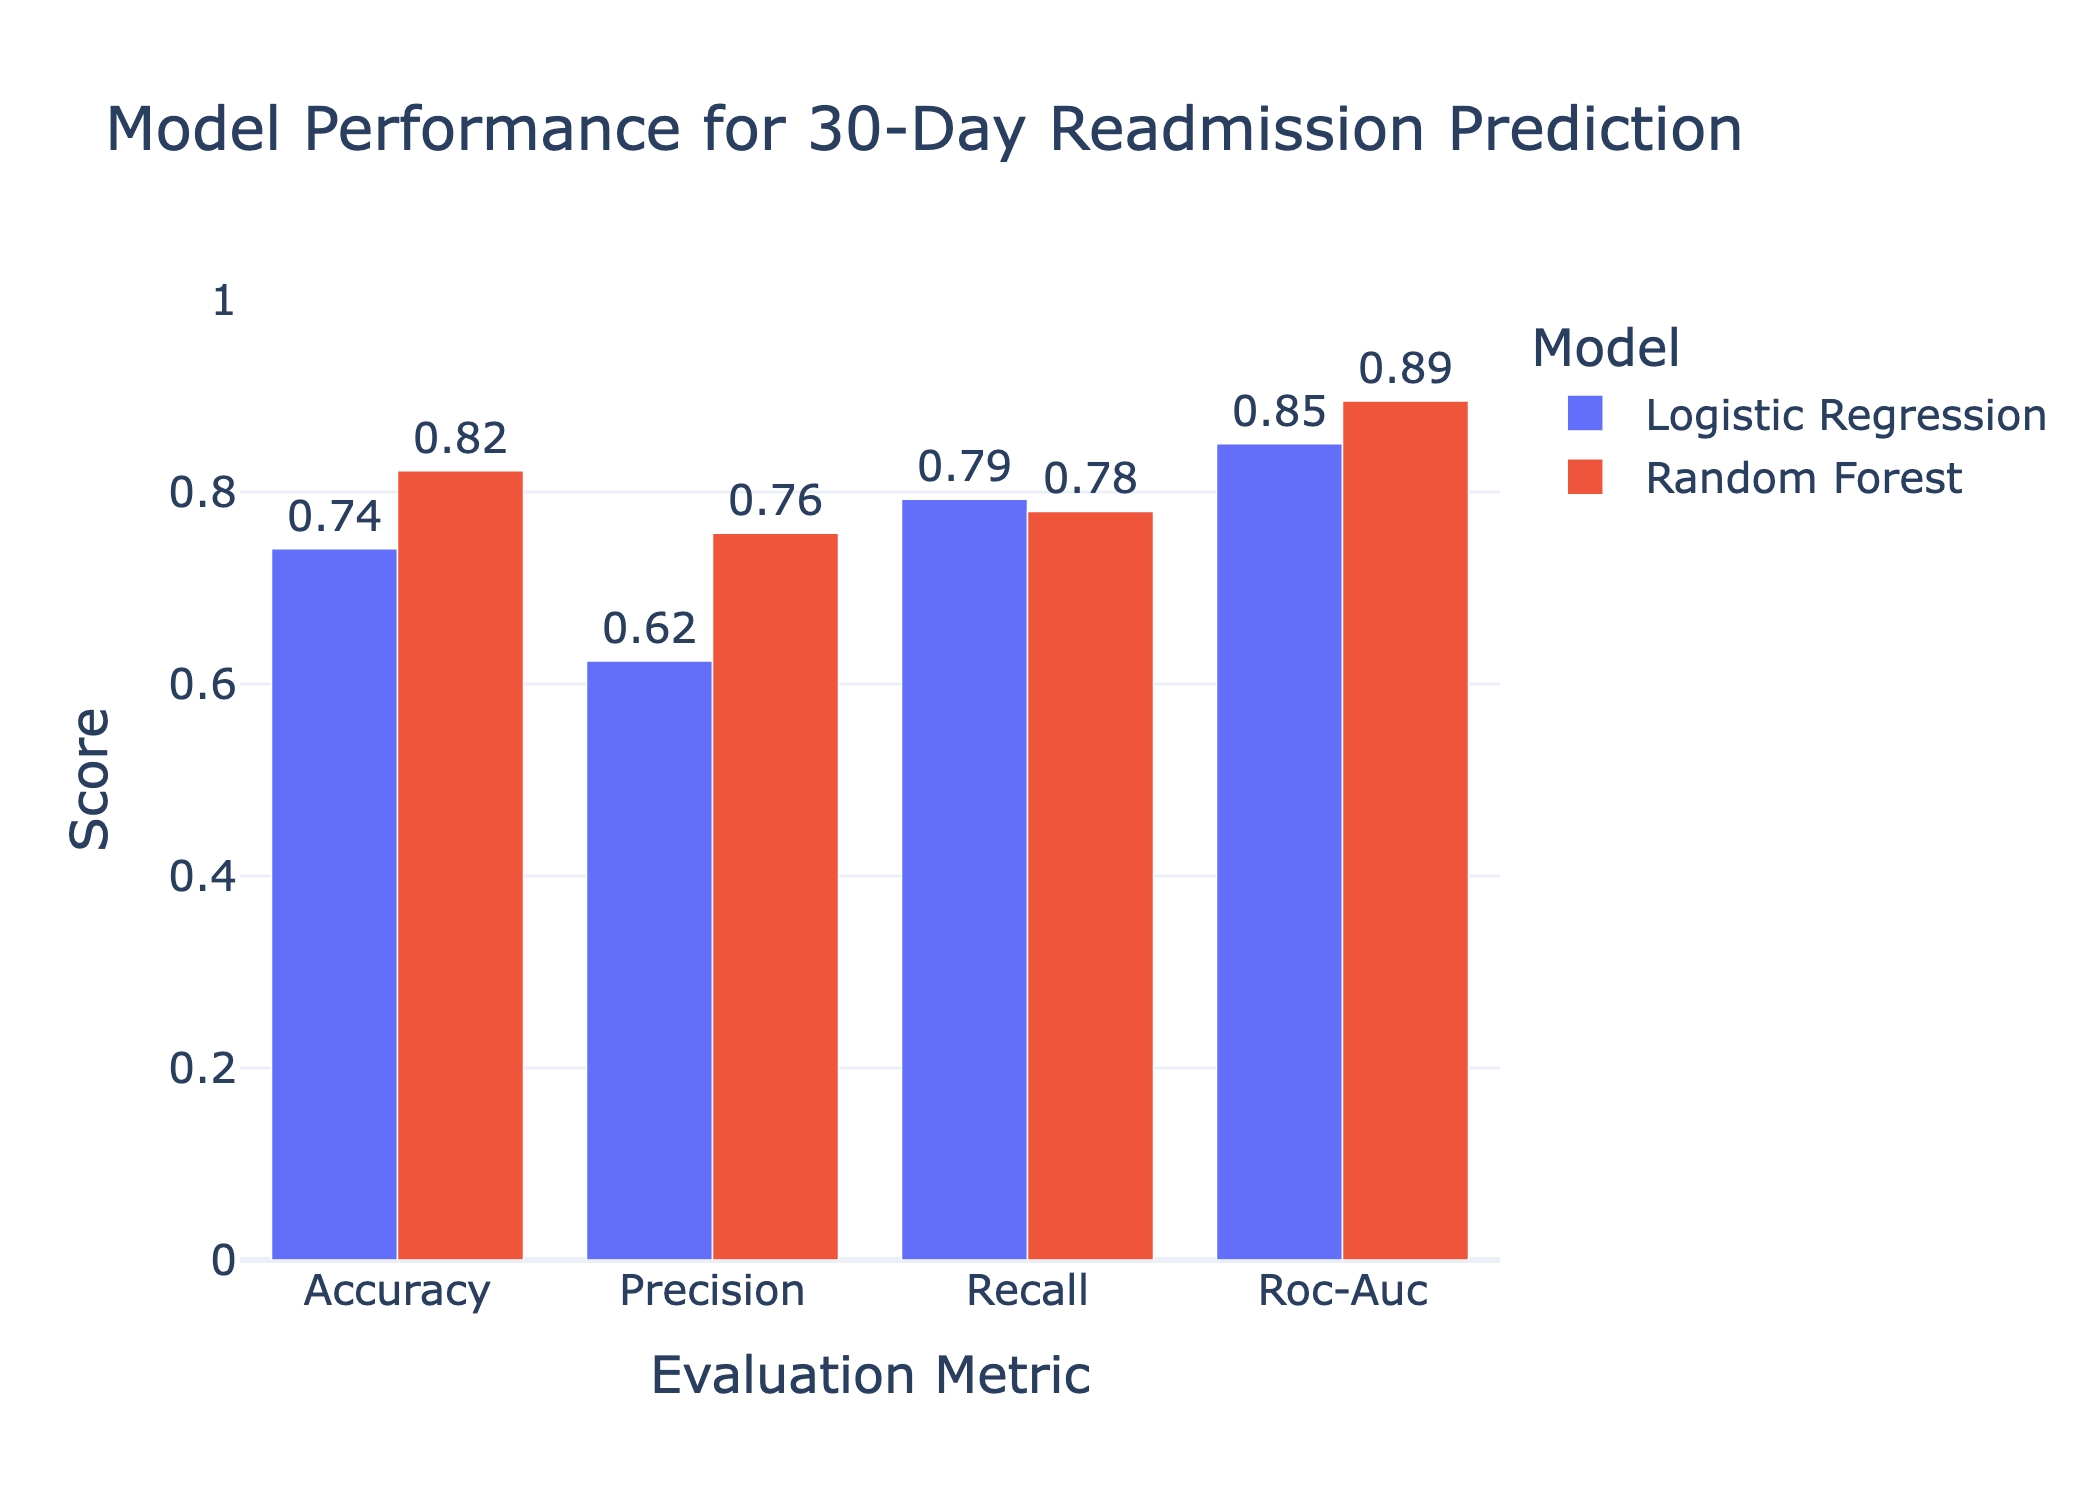

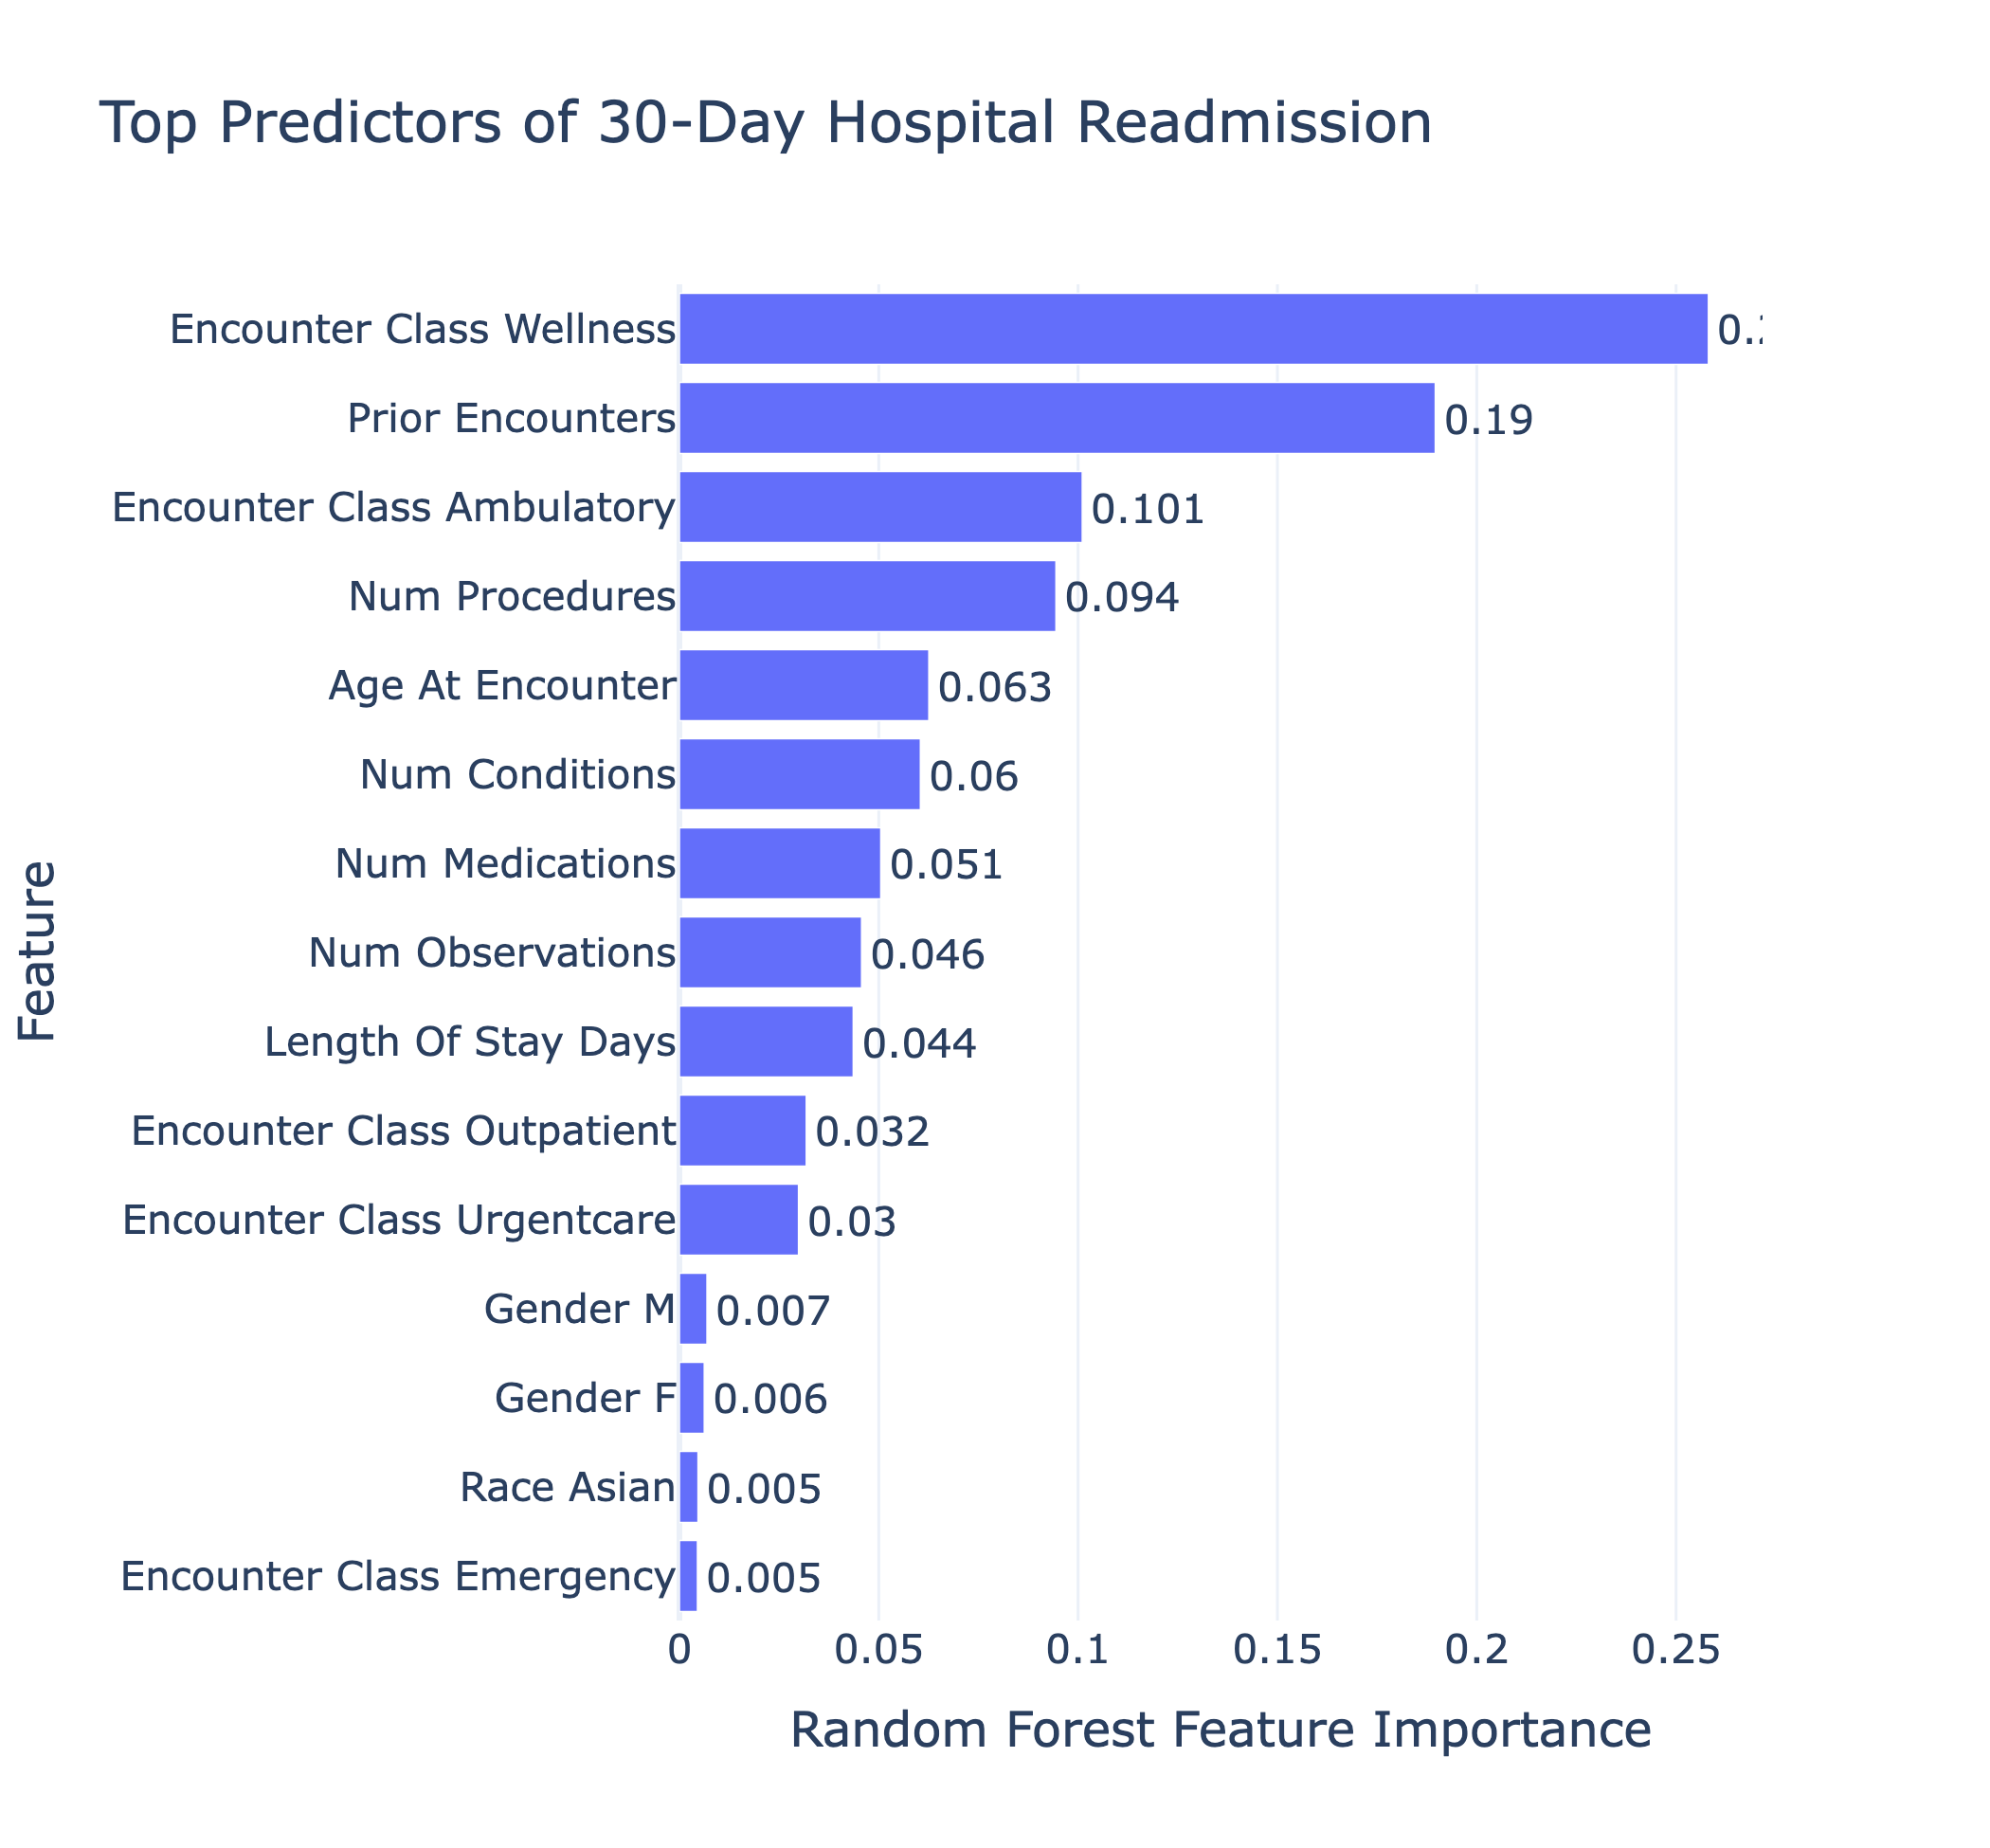

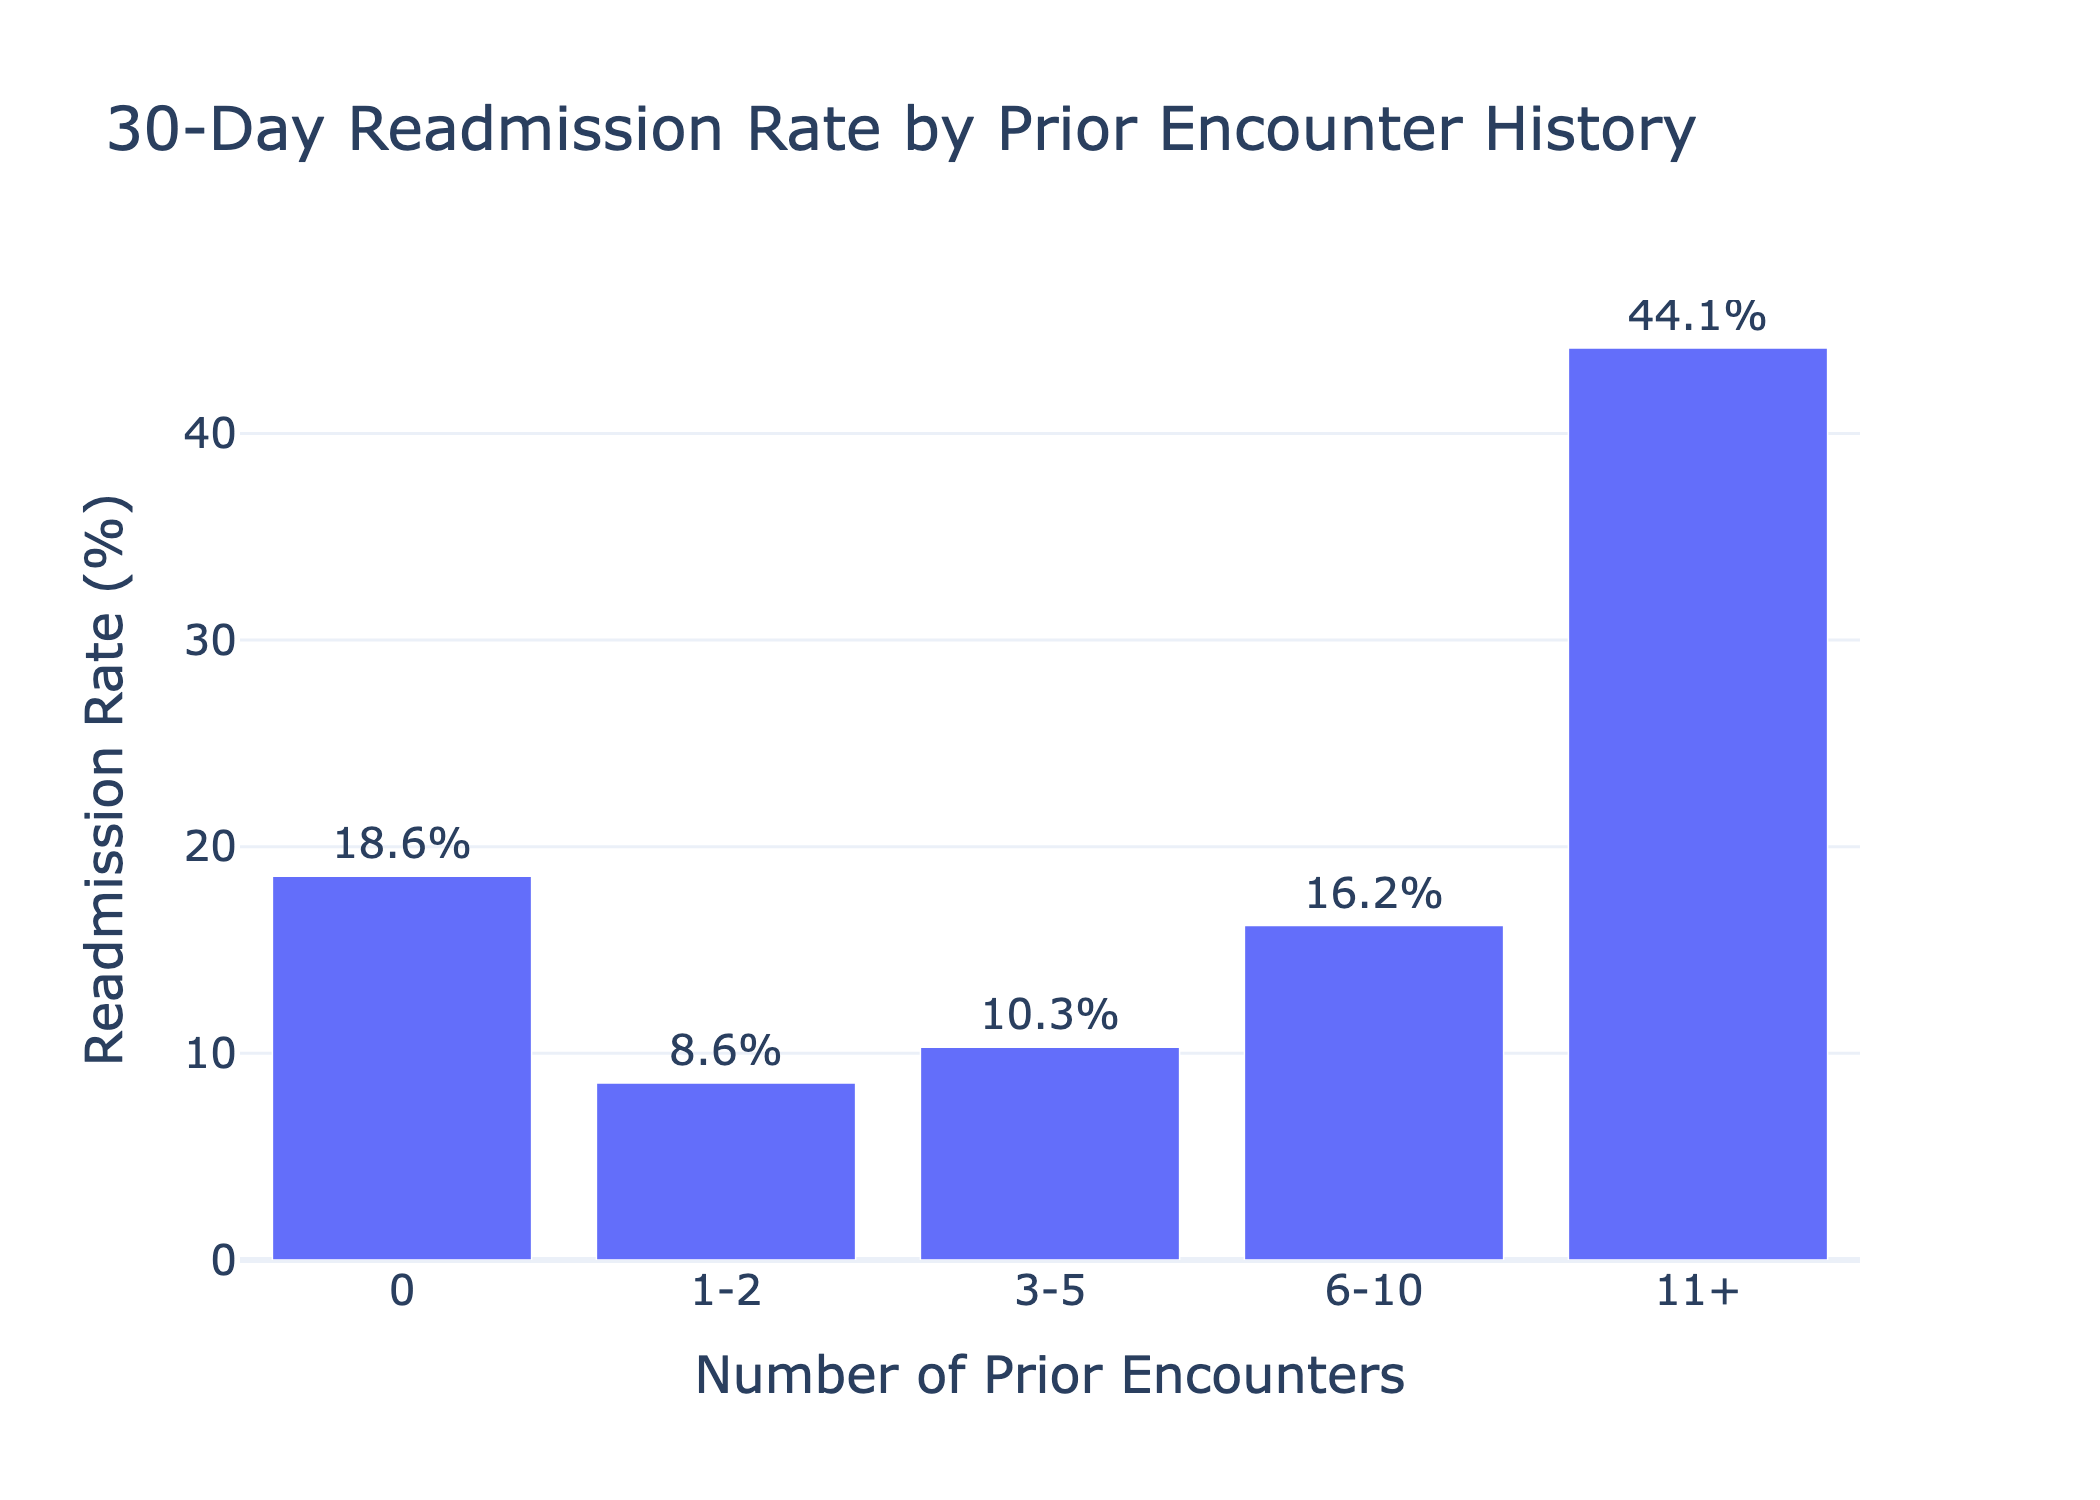

In [6]:
from IPython.display import Image, display

display(Image(filename=PROJECT_ROOT / "outputs" / "figures" / "model_comparison.png"))
display(Image(filename=PROJECT_ROOT / "outputs" / "figures" / "feature_importance.png"))
display(Image(filename=PROJECT_ROOT / "outputs" / "figures" / "readmission_by_prior_encounters.png"))

### Visualization Rationale

The model comparison chart allows direct evaluation of logistic regression versus random forest across multiple metrics.

The feature importance chart supports the second project objective: identifying which factors are most associated with readmission risk.

The prior encounter chart provides an intuitive operational insight: patients with heavier recent utilization histories are more likely to return within 30 days.

### Final Interpretation

The Random Forest model outperformed Logistic Regression, indicating that nonlinear relationships and interactions are important when predicting hospital readmissions.

Clinical complexity measures such as prior encounters, condition burden, and treatment intensity were among the strongest predictors.

These results suggest hospitals can use routinely collected patient data to proactively identify higher-risk patients and prioritize discharge planning, follow-up care, or care coordination efforts.